## Step 1: Import Libraries & Setup GPU

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import models

import numpy as np
from pathlib import Path
import json
from datetime import datetime
import matplotlib.pyplot as plt

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER
VRAM: 12.88 GB


## Step 2: Load Preprocessed Data (Original-Only Split)

In [2]:
# ============================================================================
# Load data from data_processed_original_only/ (split first, no augmentation)
# ============================================================================

data_path = Path('data_processed_original_only')

# Verify directory exists
assert data_path.exists(), f"Data directory not found: {data_path}"

# Load training set (ORIGINAL images only)
X_train = np.load(data_path / 'train' / 'images.npy')
y_train = np.load(data_path / 'train' / 'labels.npy')

# Load validation set (ORIGINAL images)
X_val = np.load(data_path / 'val' / 'images.npy')
y_val = np.load(data_path / 'val' / 'labels.npy')

# Load test set (ORIGINAL images)
X_test = np.load(data_path / 'test' / 'images.npy')
y_test = np.load(data_path / 'test' / 'labels.npy')

# Load metadata
with open(data_path / 'metadata.json', 'r') as f:
    metadata = json.load(f)

print("✅ Data Loaded Successfully!")
print(f"\nDataset Shape:")
print(f"  Train: {X_train.shape} | Labels: {np.bincount(y_train)}")
print(f"  Val:   {X_val.shape} | Labels: {np.bincount(y_val)}")
print(f"  Test:  {X_test.shape} | Labels: {np.bincount(y_test)}")
print(f"\n📌 Train set uses ORIGINAL images only (no augmentation)")
print(f"📌 Val & Test sets are also ORIGINAL")

✅ Data Loaded Successfully!

Dataset Shape:
  Train: (266, 224, 224, 3) | Labels: [137 129]
  Val:   (89, 224, 224, 3) | Labels: [46 43]
  Test:  (89, 224, 224, 3) | Labels: [46 43]

📌 Train set uses ORIGINAL images only (no augmentation)
📌 Val & Test sets are also ORIGINAL


## Step 3: ImageNet Normalization & Create PyTorch Tensors

In [3]:
# ImageNet normalization parameters
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def normalize_imagenet(images):
    """
    Apply ImageNet normalization
    images: (N, 224, 224, 3) with values in [0, 1]
    returns: (N, 224, 224, 3) normalized
    """
    normalized = np.zeros_like(images)
    for i in range(3):  # RGB channels
        normalized[..., i] = (images[..., i] - IMAGENET_MEAN[i]) / IMAGENET_STD[i]
    return normalized

# Apply normalization
print("Applying ImageNet normalization...")
X_train_norm = normalize_imagenet(X_train)
X_val_norm = normalize_imagenet(X_val)
X_test_norm = normalize_imagenet(X_test)

# Convert to PyTorch tensors and reshape (N, 3, 224, 224) for PyTorch
# PyTorch expects: (Batch, Channels, Height, Width)
X_train_tensor = torch.from_numpy(X_train_norm.transpose(0, 3, 1, 2)).float()
y_train_tensor = torch.from_numpy(y_train).long()

X_val_tensor = torch.from_numpy(X_val_norm.transpose(0, 3, 1, 2)).float()
y_val_tensor = torch.from_numpy(y_val).long()

X_test_tensor = torch.from_numpy(X_test_norm.transpose(0, 3, 1, 2)).float()
y_test_tensor = torch.from_numpy(y_test).long()

# Create PyTorch datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print("✅ Normalization complete and tensors created")
print(f"   Train tensor: {X_train_tensor.shape} | dtype: {X_train_tensor.dtype}")
print(f"   Val tensor: {X_val_tensor.shape} | dtype: {X_val_tensor.dtype}")
print(f"   Test tensor: {X_test_tensor.shape} | dtype: {X_test_tensor.dtype}")

Applying ImageNet normalization...
✅ Normalization complete and tensors created
   Train tensor: torch.Size([266, 3, 224, 224]) | dtype: torch.float32
   Val tensor: torch.Size([89, 3, 224, 224]) | dtype: torch.float32
   Test tensor: torch.Size([89, 3, 224, 224]) | dtype: torch.float32


## Step 4: Create Data Loaders

In [4]:
# Data loader settings
BATCH_SIZE = 32
NUM_WORKERS = 4  # 4 workers for parallel data loading

# Create data loaders (single split, no K-Fold)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("✅ Data loaders created:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ Data loaders created:
   Batch size: 32
   Train batches: 9
   Val batches: 3
   Test batches: 3


## Step 5: Build ResNet18 Model + Freeze Helpers

In [5]:
def build_model():
    """Build ResNet18 architecture."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, 2)  # Binary: Clear or Turbid
    )
    return model


def set_freeze_stage(model, freeze_stage):
    """
    freeze_stage=1: train fc only
    freeze_stage=2: train layer4 + fc
    freeze_stage=3: train layer3 + layer4 + fc
    """
    # Freeze all parameters first
    for param in model.parameters():
        param.requires_grad = False

    # Always unfreeze classification head
    for param in model.fc.parameters():
        param.requires_grad = True

    if freeze_stage >= 2:
        for param in model.layer4.parameters():
            param.requires_grad = True

    if freeze_stage >= 3:
        for param in model.layer3.parameters():
            param.requires_grad = True


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# Initialize model
model = build_model().to(device)
set_freeze_stage(model, freeze_stage=1)

total_params, trainable_params = count_parameters(model)

print("✅ ResNet18 model initialized")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters (Stage 1): {trainable_params:,}")
print("   Pre-trained: ImageNet (1000 classes)")
print("   Custom head: 512 -> 256 -> 2 (Clear/Turbid)")

✅ ResNet18 model initialized
   Total parameters: 11,308,354
   Trainable parameters (Stage 1): 131,842
   Pre-trained: ImageNet (1000 classes)
   Custom head: 512 -> 256 -> 2 (Clear/Turbid)


## Step 6: Setup Training Configuration

In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Progressive freeze training stages (no K-Fold)
STAGE_CONFIGS = [
    {
        'name': 'Stage 1 (FC only)',
        'freeze_stage': 1,
        'epochs': 15,
        'lr_fc': 1e-4,
        'min_epochs': 3,
        'early_stopping_patience': 5
    },
    {
        'name': 'Stage 2 (Unfreeze layer4 + FC)',
        'freeze_stage': 2,
        'epochs': 20,
        'lr_layer4': 3e-5,
        'lr_fc': 3e-4,
        'min_epochs': 5,
        'early_stopping_patience': 8
    }
]

WEIGHT_DECAY = 5e-4
LR_PATIENCE = 3
TOTAL_PLANNED_EPOCHS = sum(stage['epochs'] for stage in STAGE_CONFIGS)

print("✅ Training Configuration (Progressive Freeze):")
print("   Loss: CrossEntropyLoss")
for stage in STAGE_CONFIGS:
    if stage['freeze_stage'] == 1:
        lr_info = f"lr_fc={stage['lr_fc']}"
    else:
        lr_info = f"lr_layer4={stage['lr_layer4']}, lr_fc={stage['lr_fc']}"
    print(f"   - {stage['name']}: epochs={stage['epochs']}, {lr_info}, min_epochs={stage['min_epochs']}, patience={stage['early_stopping_patience']}")
print(f"   Weight decay: {WEIGHT_DECAY}")
print(f"   Scheduler patience: {LR_PATIENCE}")
print(f"   Total planned epochs: {TOTAL_PLANNED_EPOCHS}")

✅ Training Configuration (Progressive Freeze):
   Loss: CrossEntropyLoss
   - Stage 1 (FC only): epochs=15, lr=0.0001, min_epochs=3, patience=5
   - Stage 2 (Unfreeze layer4 + FC): epochs=20, lr=0.0003, min_epochs=5, patience=8
   - Stage 3 (Unfreeze layer3 + layer4 + FC): epochs=15, lr=0.0001, min_epochs=5, patience=8
   Weight decay: 0.0005
   Scheduler patience: 3
   Total planned epochs: 50


## Step 7: Training Loop (Progressive Freeze, No K-Fold)

In [ ]:
from copy import deepcopy
from tqdm import tqdm

# Training history (single run)
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = -1.0
best_val_loss = float('inf')
best_model_state = None
best_stage_name = None
best_epoch = 0
global_epoch = 0

print("🚀 Starting progressive-freeze training...\n")
start_time = datetime.now()

for stage_idx, stage in enumerate(STAGE_CONFIGS, start=1):
    # Apply freeze strategy for this stage
    set_freeze_stage(model, stage['freeze_stage'])

    # New optimizer for currently trainable parameters
    if stage['freeze_stage'] == 1:
        param_groups = [
            {'params': model.fc.parameters(), 'lr': stage['lr_fc']}
        ]
    else:
        param_groups = [
            {'params': model.layer4.parameters(), 'lr': stage['lr_layer4']},
            {'params': model.fc.parameters(), 'lr': stage['lr_fc']}
        ]

    optimizer = optim.Adam(
        param_groups,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=LR_PATIENCE,
        threshold=1e-4
    )

    _, stage_trainable_params = count_parameters(model)

    print("\n" + "="*70)
    print(f"{stage['name']} | Trainable params: {stage_trainable_params:,}")
    print("="*70)

    stage_patience_counter = 0
    stage_stopped_early = False

    for epoch_in_stage in range(stage['epochs']):
        global_epoch += 1

        # ========== TRAINING PHASE ==========
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_pbar = tqdm(
            train_loader,
            desc=f"{stage['name']} Epoch {epoch_in_stage+1}/{stage['epochs']} [TRAIN]",
            leave=False
        )
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total

        # ========== VALIDATION PHASE ==========
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            val_pbar = tqdm(
                val_loader,
                desc=f"{stage['name']} Epoch {epoch_in_stage+1}/{stage['epochs']} [VAL]",
                leave=False
            )
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch [{global_epoch}/{TOTAL_PLANNED_EPOCHS}] "
            f"| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
            f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
        )

        scheduler.step(val_loss)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_stage_name = stage['name']
            best_epoch = global_epoch
            best_model_state = deepcopy(model.state_dict())
            stage_patience_counter = 0

            checkpoint_path = 'resnet18_best.pth'
            torch.save(
                {
                    'epoch': global_epoch,
                    'stage': stage['name'],
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': val_acc,
                    'val_loss': val_loss
                },
                checkpoint_path
            )
            print(f"  ✅ Best model saved: {val_acc:.2f}% ({stage['name']})")
        else:
            stage_patience_counter += 1
            print(f"  ⏳ No improvement ({stage_patience_counter}/{stage['early_stopping_patience']})")

        # Early stopping is applied per stage so later stages still run
        if epoch_in_stage + 1 >= stage['min_epochs'] and stage_patience_counter >= stage['early_stopping_patience']:
            stage_stopped_early = True
            print(f"  ⛔ Early stopping in {stage['name']} at global epoch {global_epoch}")
            break

    if stage_stopped_early:
        print(f"  ↪ Moving to next stage after {stage['name']}")

if best_model_state is None:
    raise RuntimeError("No best model state found during training")

# Load best model state for saving final model
model.load_state_dict(best_model_state)

elapsed_time = datetime.now() - start_time
print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"Best Stage: {best_stage_name}")
print(f"Best Epoch: {best_epoch}")
print(f"Best Val Accuracy: {best_val_acc:.2f}%")
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total Trained Epochs: {len(history['train_loss'])}")
print(f"Stages Configured: {len(STAGE_CONFIGS)}")
print(f"Training Time: {elapsed_time}")

🚀 Starting progressive-freeze training...


Stage 1 (FC only) | Trainable params: 131,842


Epoch [1/50] | Train Loss: 0.6950 | Train Acc: 55.64% | Val Loss: 0.6614 | Val Acc: 64.04%
  ✅ Best model saved: 64.04% (Stage 1 (FC only))


Epoch [2/50] | Train Loss: 0.6471 | Train Acc: 62.78% | Val Loss: 0.6342 | Val Acc: 68.54%
  ✅ Best model saved: 68.54% (Stage 1 (FC only))


Epoch [3/50] | Train Loss: 0.5955 | Train Acc: 73.31% | Val Loss: 0.6097 | Val Acc: 76.40%
  ✅ Best model saved: 76.40% (Stage 1 (FC only))


Epoch [4/50] | Train Loss: 0.5707 | Train Acc: 73.31% | Val Loss: 0.5852 | Val Acc: 82.02%
  ✅ Best model saved: 82.02% (Stage 1 (FC only))


...

Epoch [23/50] | Train Loss: 0.0170 | Train Acc: 98.87% | Val Loss: 0.6204 | Val Acc: 83.15%
  ⏳ No improvement (4/8)


Epoch [24/50] | Train Loss: 0.0084 | Train Acc: 100.00% | Val Loss: 0.4425 | Val Acc: 88.76%
  ⏳ No improvement (5/8)


Epoch [25/50] | Train Loss: 0.0163 | Train Acc: 99.25% | Val Loss: 0.9415 | Val Acc: 83.15%
  ⏳ No improvement (6/8)


Epoch [26/50] | Train Loss: 0.0082 | Train Acc: 100.00% | Val Loss: 0.5844 | Val Acc: 88.76%
  ⏳ No improvement (7/8)


Epoch [27/50] | Train Loss: 0.0176 | Train Acc: 99.25% | Val Loss: 0.5005 | Val Acc: 87.64%
  ⏳ No improvement (8/8)
  ⛔ Early stopping in Stage 3 (Unfreeze layer3 + layer4 + FC) at global epoch 27
  ↪ Moving to next stage after Stage 3 (Unfreeze layer3 + layer4 + FC)

TRAINING SUMMARY
Best Stage: Stage 2 (Unfreeze layer4 + FC)
Best Epoch: 11
Best Val Accuracy: 88.76%
Best Val Loss: 0.3354
Total Trained Epochs: 27
Stages Configured: 3
Training Time: 0:02:14.241514


## Step 8: Save Model & Metadata

In [ ]:
# Save final model (best checkpoint from progressive freeze)
final_model_path = "resnet18_final_best_practice.pth"
torch.save(model.state_dict(), final_model_path)

stage_lr_metadata = []
for stage in STAGE_CONFIGS:
    lr_entry = {
        'stage': stage['name'],
        'lr_fc': stage['lr_fc']
    }
    if 'lr_layer4' in stage:
        lr_entry['lr_layer4'] = stage['lr_layer4']
    stage_lr_metadata.append(lr_entry)

# Save metadata
training_metadata = {
    'model': 'ResNet18',
    'dataset': 'data_processed_original_only',
    'dataset_description': 'Split first (70/15/15), no augmentation applied',
    'cv_enabled': False,
    'freeze_strategy': 'progressive',
    'stage_configs': STAGE_CONFIGS,
    'best_stage': best_stage_name,
    'best_epoch': int(best_epoch),
    'train_images': int(X_train.shape[0]),
    'train_images_original': metadata['train_images_original'],
    'val_images': int(X_val.shape[0]),
    'test_images': int(X_test.shape[0]),
    'best_val_accuracy': float(best_val_acc),
    'best_val_loss': float(best_val_loss),
    'total_epochs': len(history['train_loss']),
    'batch_size': BATCH_SIZE,
    'learning_rates': stage_lr_metadata,
    'weight_decay': WEIGHT_DECAY,
    'optimizer': 'Adam',
    'scheduler': 'ReduceLROnPlateau',
    'training_date': datetime.now().isoformat(),
    'device': str(device),
    'training_time': str(elapsed_time),
    'training_history': history
}

metadata_path = "resnet18_metadata_best_practice.json"
with open(metadata_path, 'w') as f:
    json.dump(training_metadata, f, indent=2)

print(f"✅ Model saved: {final_model_path}")
print(f"✅ Metadata saved: {metadata_path}")
print(f"\n📊 Training Results:")
print(f"   Best Stage: {best_stage_name}")
print(f"   Best Val Accuracy: {best_val_acc:.2f}%")
print(f"   Best Val Loss: {best_val_loss:.4f}")
print(f"   Total Epochs Trained: {len(history['train_loss'])}")
print(f"   Training Time: {elapsed_time}")

✅ Model saved: resnet18_final_best_practice.pth
✅ Metadata saved: resnet18_metadata_best_practice.json

📊 Training Results:
   Best Stage: Stage 2 (Unfreeze layer4 + FC)
   Best Val Accuracy: 91.01%
   Best Val Loss: 0.4122
   Total Epochs Trained: 35
   Training Time: 0:02:54.016405


## Step 9: Plot Training History

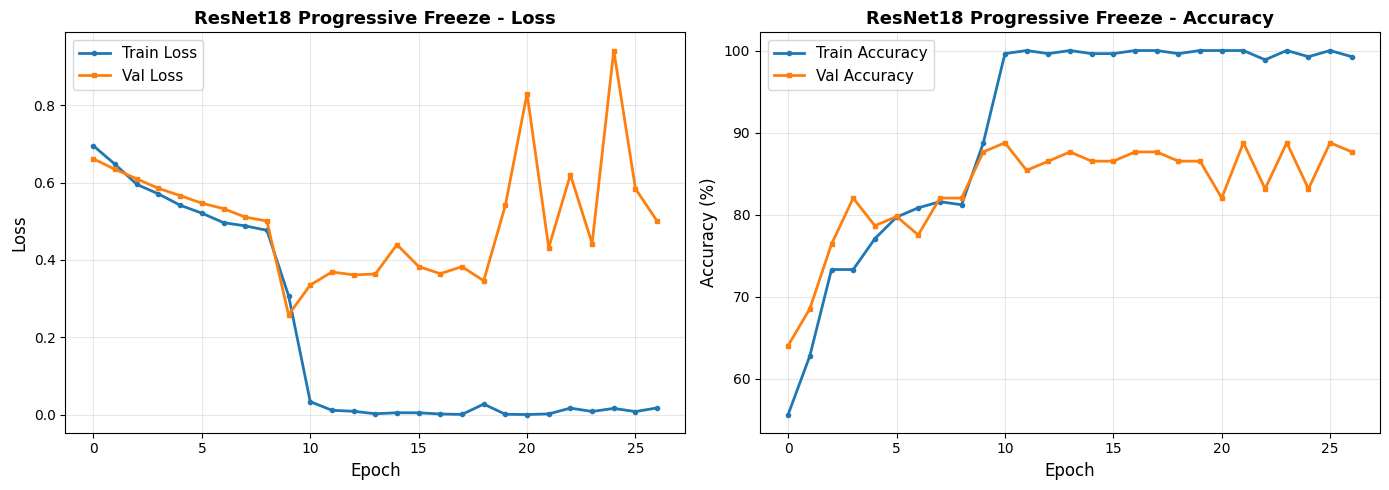

📊 Training visualization saved: resnet18_training_history_progressive_freeze.png


In [8]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=3)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=3)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('ResNet18 Progressive Freeze - Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2, marker='o', markersize=3)
axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2, marker='s', markersize=3)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('ResNet18 Progressive Freeze - Accuracy', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet18_training_history_progressive_freeze.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 Training visualization saved: resnet18_training_history_progressive_freeze.png')